In [36]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss, roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# 1. 데이터 로드 및 전처리
titanic = sns.load_dataset('titanic')

# 결측치 처리
titanic['age'].fillna(titanic['age'].median(), inplace=True) # Age 결측치를 중앙값으로 대체
titanic['embarked'].fillna('S', inplace=True) # Embarked 결측치를 최빈값으로 대체

# 범주형 변수 인코딩
titanic=pd.get_dummies(titanic,columns = ['sex','embarked','class','who','deck','embark_town','alone'],drop_first=True)

C:\Users\ghfjg\AppData\Local\Temp\ipykernel_20104\394614227.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True) # Age 결측치를 중앙값으로 대체
C:\Users\ghfjg\AppData\Local\Temp\ipykernel_20104\394614227.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [38]:
titanic = titanic*1
X = titanic.drop(['survived', 'alive'], axis = 1)
y = titanic['survived']

In [39]:
# train, test 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 111)

early_stopping_rounds 36
Best iteration : 26
Best validation loss : 0.4141


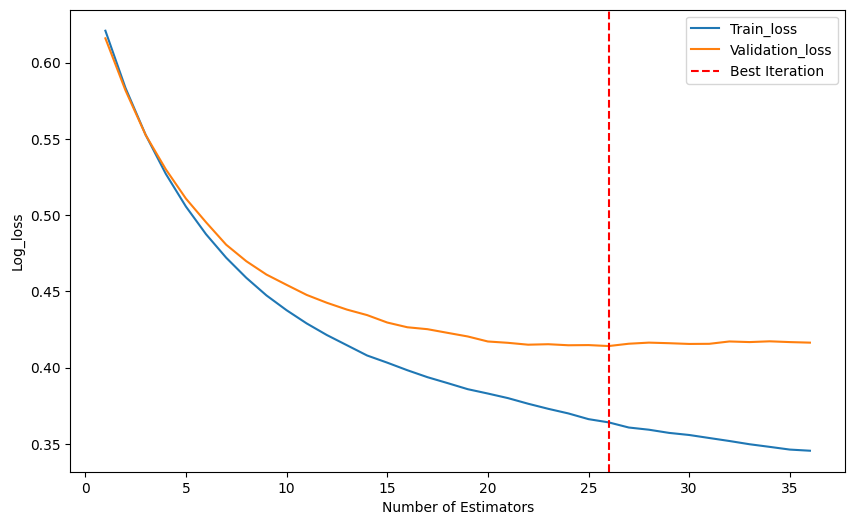

In [40]:
# train,test 분할

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2, random_state=111)

## gbm 제공하는 조기종료의 형태 구현

n_estimators = 1000
early_stopping_rounds = 10

train_loss=[]
val_loss=[]

best_iter = 0
best_val_loss =float('inf')
stopping_rounds = 0

for n in range(1, n_estimators+1):
    #모델 학습
    gbm=GradientBoostingClassifier(
    n_estimators = n,
    learning_rate= 0.1,
    max_depth = 3,
    random_state=111
    )
    gbm.fit(X_train, y_train)
    
    #손실 계산
    current_train_loss = log_loss(y_train, gbm.predict_proba(X_train))
    current_val_loss = log_loss(y_val, gbm.predict_proba(X_val))
    
    train_loss.append(current_train_loss)
    val_loss.append(current_val_loss)
    
    # 조기 종료 조건
    # best 스코어가 나오고 current_loss , best_loss 비교해서 조건을 만들면 된다.
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_iter = n
        stopping_rounds = 0
    else:
        stopping_rounds +=1
        if stopping_rounds >= early_stopping_rounds:
            print(f'early_stopping_rounds {n}')
            break

#최적 모델 정보 출력
print(f'Best iteration : {best_iter}')
print(f'Best validation loss : {best_val_loss:.4f}')

#학습 곡선을 그림으로 그려보자
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_loss)+ 1), train_loss, label='Train_loss')
plt.plot(range(1, len(val_loss)+ 1), val_loss, label='Validation_loss')
plt.axvline(best_iter, color='r',linestyle='--',label = 'Best Iteration')
plt.legend()
plt.xlabel('Number of Estimators')
plt.ylabel('Log_loss')
plt.show()

In [41]:
# 피처의 중요도
feature_importances = gbm.feature_importances_
importance_df = pd.DataFrame({'Feature' : X.columns, 'Importance' : feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

<Axes: xlabel='Importance', ylabel='Feature'>

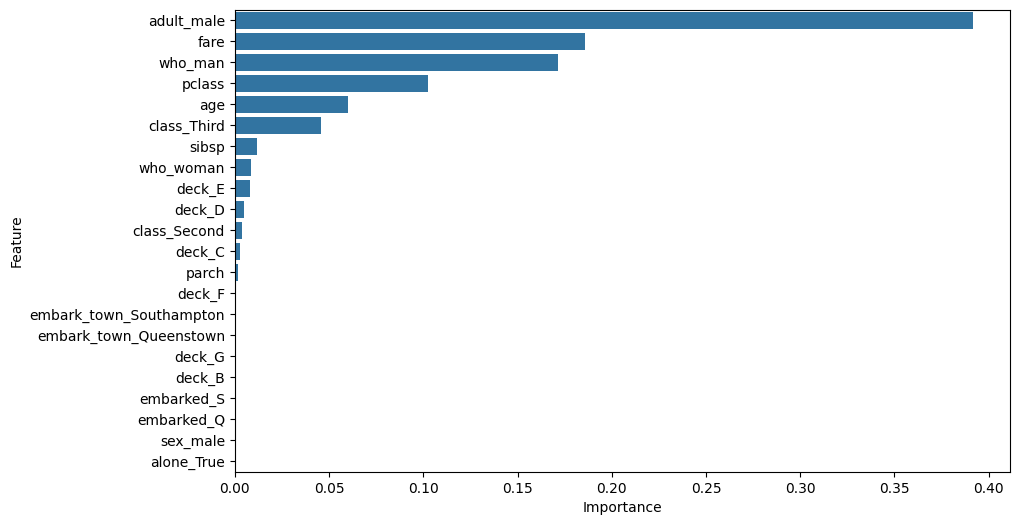

In [42]:
plt.figure(figsize = (10,6))
sns.barplot(x='Importance', y = 'Feature', data = importance_df)

accuracy : 0.8212
pre : 0.7931
recall : 0.6970
f1 : 0.7419


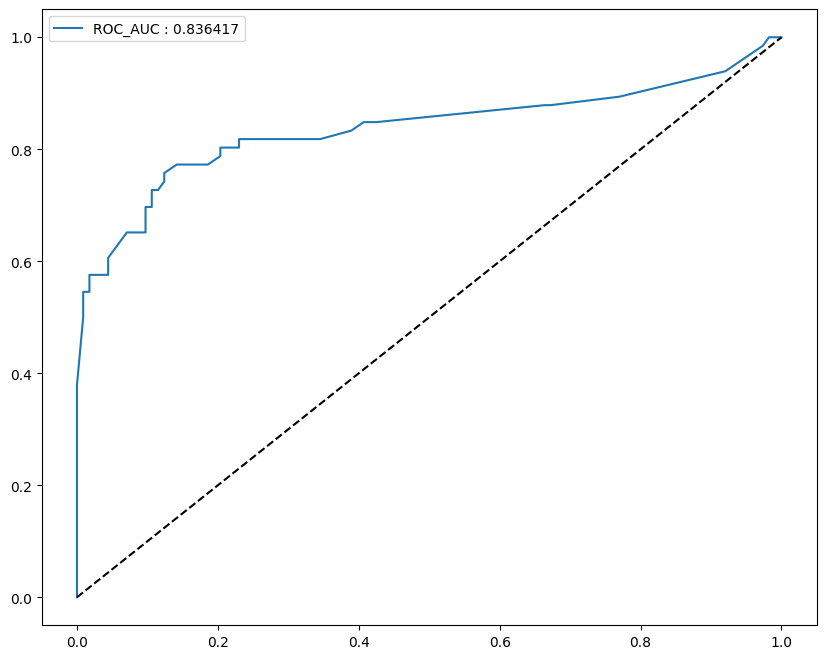

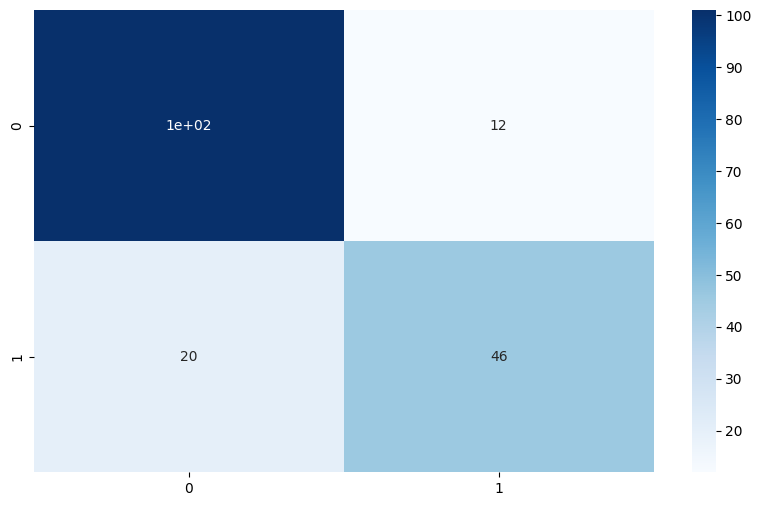

In [43]:
## Roc_Auc 커브 & 혼동행렬 & 평가지표까지
## best_iter로 학습

gbm=GradientBoostingClassifier(
    n_estimators = best_iter,
    learning_rate= 0.1,
    max_depth = 3,
    random_state=111
    )
gbm.fit(X_train, y_train)

y_pred_proba = gbm.predict_proba(X_val)[:,1]
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

## roc curve
plt.figure(figsize=(10,8))
plt.plot(fpr, tpr, label=f'ROC_AUC : {roc_auc_score(y_val, y_pred_proba):2f}')
plt.plot([0,1],[0,1],'k--')
plt.legend()

## 혼동행렬 그리기
y_pred = gbm.predict(X_val)
conf_matrix = confusion_matrix(y_val, y_pred)

## 시각화

plt.figure(figsize=(10,6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues')

# 최적의 평가지표

acc= accuracy_score(y_val, y_pred)
pre= precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f'accuracy : {acc:.4f}')
print(f'pre : {pre:.4f}')
print(f'recall : {recall:.4f}')
print(f'f1 : {f1:.4f}')

### SVM과 GBM 같이 비교해보기

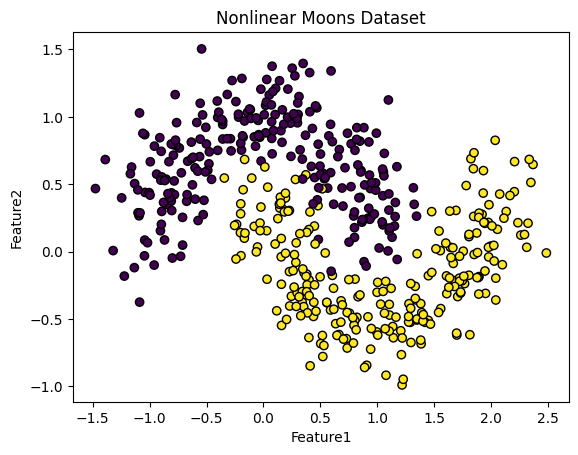

In [46]:
from sklearn.datasets import make_moons
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 비선형 데이터 생성 (make_moon)
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# 데이터 프레임으로 변환
data = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
data['Target'] = y

# 데이터 시각화
plt.scatter(data['Feature1'],data['Feature2'], c=data['Target'], cmap = 'viridis', edgecolor='k')
plt.title('Nonlinear Moons Dataset')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.show()

In [57]:
# 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(data[['Feature1','Feature2']], data['Target'], test_size=0.2, random_state=111)

In [59]:
#SVM
from sklearn.svm import SVC
from sklearn.metrics import classification_report

#SVM RBF
svc_model = SVC(kernel='rbf', probability = True, random_state=111)
svc_model.fit(X_train, y_train)

#gbm
gbm_model = GradientBoostingClassifier(random_state=111)
gbm_model.fit(X_train, y_train)

# 성능평가
print('SVM:', classification_report(y_test, svc_model.predict(X_test)))
print('gbm:', classification_report(y_test, gbm_model.predict(X_test)))

SVM:               precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       1.00      0.98      0.99        61

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

gbm:               precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       1.00      0.98      0.99        61

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [62]:
## 둘의 구분하는 그래프를 그려서 decision_boundary를 통해 이해해보자!
from matplotlib.colors import ListedColormap

# 시각화 함수
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
    y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(["#FFAAAA", "#AAAAFF"]))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor="k", cmap="viridis")
    plt.title(title)

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


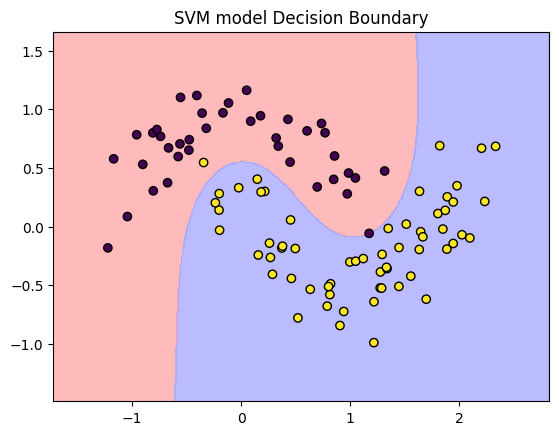

In [63]:
plot_decision_boundary(svc_model, X_test, y_test, 'SVM model Decision Boundary')

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


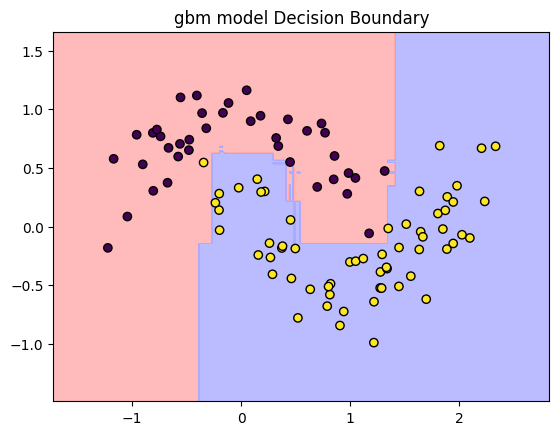

In [64]:
plot_decision_boundary(gbm_model, X_test, y_test, 'gbm model Decision Boundary')

In [67]:
# 예제 데이터를 이용해서 SVC, GBM의 차이를 조금 더 이해하기
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=500,
    n_features = 4,
    n_informative = 2,
    n_classes = 2,
    n_clusters_per_class=1,
    flip_y = 0.02,
    class_sep = 1.5,
    random_state=111)

In [69]:
data= pd.DataFrame(X, columns=['Income', 'Age', 'Saving','Spending'])
data['target'] = y

In [70]:
data

,Income,Age,Saving,Spending,target
0,0.849073,-0.983031,0.911660,1.915237,1
1,0.955577,-1.298634,1.137769,2.341470,1
2,0.419446,-1.645021,1.124158,2.067541,1
3,-0.185829,1.514344,-0.954566,-1.675793,0
4,-0.097968,1.356780,-0.827776,-1.423597,0
...,...,...,...,...,...
495,-0.119256,1.267540,-0.784447,-1.361460,0
496,-0.248618,-2.232164,1.197578,1.876625,1
497,-0.319941,1.240144,-0.848973,-1.562910,0
498,0.695471,-1.629063,1.225533,2.365630,1


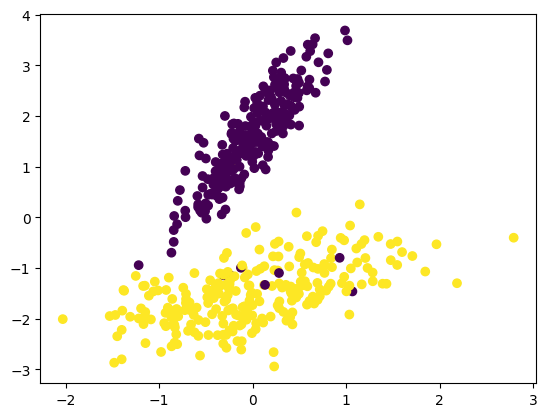

In [71]:
plt.scatter(data['Income'], data['Age'], c = data['target'], cmap='viridis')

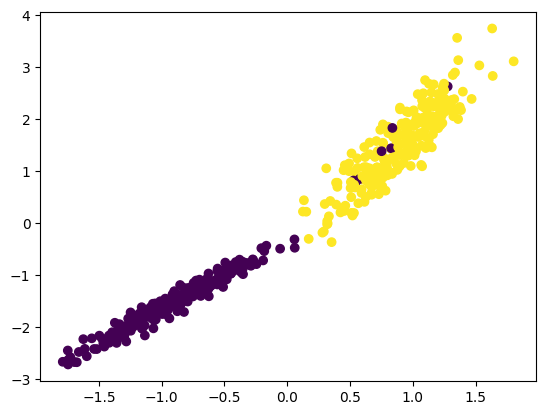

In [72]:
plt.scatter(data['Saving'], data['Spending'], c=data['target'], cmap='viridis')

### 가상의 예제 데이터 셋을 만들어서 SVM, GBM의 원리를 확인해보자!

In [73]:
# 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(data[['Income','Age','Saving','Spending']],
                                                    data['target'], test_size = 0.2, random_state = 111)

In [74]:
# SVM RBF
svc_model = SVC(kernel ='rbf', probability = True, random_state=111)
svc_model.fit(X_train, y_train)

# gbm
gbm_model=GradientBoostingClassifier(random_state=111)
gbm_model.fit(X_train, y_train)

# 성능평가
print('SVM')
print(classification_report(y_test, svc_model.predict(X_test)))

print('GBM')
print(classification_report(y_test, gbm_model.predict(X_test)))

SVM
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        52
           1       0.96      1.00      0.98        48

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

GBM
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        52
           1       0.98      0.98      0.98        48

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [75]:
# 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(data[['Income','Age']],
                                                    data['target'], test_size = 0.2, random_state = 111)

In [76]:
# SVM RBF
svc_model = SVC(kernel ='rbf', probability = True, random_state=111)
svc_model.fit(X_train, y_train)

# gbm
gbm_model=GradientBoostingClassifier(random_state=111)
gbm_model.fit(X_train, y_train)

# 성능평가
print('SVM')
print(classification_report(y_test, svc_model.predict(X_test)))

print('GBM')
print(classification_report(y_test, gbm_model.predict(X_test)))

SVM
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        52
           1       0.96      1.00      0.98        48

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

GBM
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        52
           1       0.98      0.94      0.96        48

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


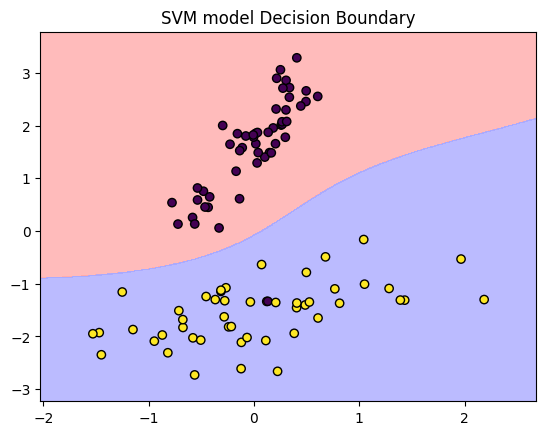

In [79]:
plot_decision_boundary(svc_model, X_test, y_test, 'SVM model Decision Boundary')

D:\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


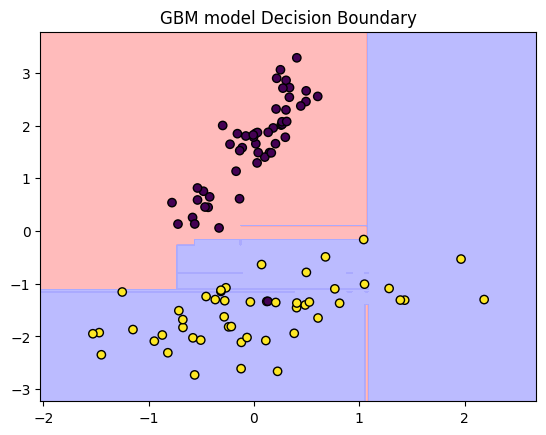

In [80]:
plot_decision_boundary(gbm_model, X_test, y_test, 'GBM model Decision Boundary')

In [ ]:
|